# Frame similarity vs static–dynamic similarity latency

For every stimulus, this notebook:

1. averages the static **last-frame** response and the static **2250-ms** (or 2000-ms) frame response in the same window (`static_window_ms`) and correlates the two population vectors across channels (*frame similarity*);
2. correlates the window-averaged last-frame pattern with the **same stimulus's** movie response at every time sample (raw lagged correlation, no dRSA);
3. estimates the centroid (and peak) of that curve inside `dynamic_window_ms`;
4. correlates the centroid latency with the frame similarity over stimuli.

Hypothesis: the more similar the earlier and last frames, the earlier the movie response already resembles the last-frame response, so frame similarity and centroid latency should be negatively associated.

In [42]:
import csv
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / "config.yaml").is_file()
)
with open(PROJECT_ROOT / "config.yaml", "r") as file:
    paths = yaml.safe_load(file)[ENV]["paths"]
# end with open
sys.path.extend([paths["src_path"], paths["useful_stuff_path"]])

from project_specific_utils.frame_similarity_latency import (
    compute_anticipation_partial,
    compute_dynamic_autocorrelation_latency,
    compute_frame_similarity_latency,
    compute_frame_similarity_rsa_latency,
    compute_lagged_max_latency,
    compute_regression_fit_latency,
    dynamic_window_regression_fit,
    dynamic_window_similarity,
    frame_similarity_timecourse_association,
    load_frame_similarity_rasters,
    plot_anticipation_partial,
    plot_centroid_example,
    plot_frame_similarity_latency,
    plot_mean_cross_temporal,
    plot_static_dynamic_window_similarity,
    plot_population_rsa_curve,
    plot_timecourse_association,
    similarity_curve_centroids,
)

In [60]:
@dataclass
class Cfg:
    static_exp_name: str = "baby1_260718to27" #"red_20260726to0922"# "red_20260726to27"
    dynamic_exp_name: str = "baby1_260716to24" #"red_20260720to0921" # "red_20260720to24"

    # MATLAB channel numbers are one-based and both endpoints are inclusive.
    good_channels: tuple[int, int] | None =  (84, 186) #(1,64)#
    # Optionally keep only the reliable channels of static_exp_name in that range.
    use_reliable_channels: bool = True
    source_fs: float = 1000
    neural_fs: float = 100
    center_neural_trials: bool = False
    # Center every window-averaged pattern across stimuli after averaging.
    center_window_averages: bool = True

    # "2250ms" or "2000ms": static frame compared with the last frame.
    earlier_frame: str = "2250ms"
    static_window_ms: tuple[float, float] = (80, 250)
    dynamic_window_ms: tuple[float, float] = (1500, 2550)
    last_frame_time_ms: float = 2500
    # Centroid weights are max(r - fraction * peak_r, 0); 0 uses all positive r.
    threshold_fraction: float = 0.5
    # None keeps the raw curves; a positive sigma smooths before the centroid.
    smoothing_sigma_ms: float | None = 30
    # Distance metric of the static-window and movie RDMs (RSA section).
    rdm_metric: str = "cosine_cnt"
    # Half-open static last-frame times entering the lagged max (lagged section).
    lag_static_search_ms: tuple[float, float] = (50, 400)
    # Half-open movie windows of the anticipation test (partial-correlation section).
    anticipation_test_window_ms: tuple[float, float] = (2300, 2550)
    anticipation_baseline_window_ms: tuple[float, float] = (1000, 1500)
    # Movie autocorrelation section: half-open reference window and earlier centroid window.
    autocorr_reference_window_ms: tuple[float, float] = (2500, 2600)
    autocorr_centroid_window_ms: tuple[float, float] = (1500, 2500)
    # Regression section: relative ridge penalty and movie centroid window.
    ridge_alpha: float = 1.0
    regression_centroid_window_ms: tuple[float, float] = (1500, 2400)
    # Movie window-pair section: two half-open movie windows correlated per stimulus.
    movie_first_window_ms: tuple[float, float] = (2200, 2250)
    movie_second_window_ms: tuple[float, float] = (2450, 2500)

    example_stimulus_index: int = 0
    annotate_stimuli: bool = False
    save_figures: bool = False
    figure_dpi: int = 160
# EOF

cfg = Cfg()
cfg

Cfg(static_exp_name='baby1_260718to27', dynamic_exp_name='baby1_260716to24', good_channels=(84, 186), use_reliable_channels=True, source_fs=1000, neural_fs=100, center_neural_trials=False, center_window_averages=True, earlier_frame='2250ms', static_window_ms=(80, 250), dynamic_window_ms=(1500, 2550), last_frame_time_ms=2500, threshold_fraction=0.5, smoothing_sigma_ms=30, rdm_metric='cosine_cnt', lag_static_search_ms=(50, 400), anticipation_test_window_ms=(2300, 2550), anticipation_baseline_window_ms=(1000, 1500), autocorr_reference_window_ms=(2500, 2600), autocorr_centroid_window_ms=(1500, 2500), ridge_alpha=1.0, regression_centroid_window_ms=(1500, 2400), movie_first_window_ms=(2200, 2250), movie_second_window_ms=(2450, 2500), example_stimulus_index=0, annotate_stimuli=False, save_figures=False, figure_dpi=160)

## Load and align the static and movie responses

In [44]:
data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_natraster_img.mat"
dynamic_path = data_dir / f"{cfg.dynamic_exp_name}_natraster_vid.mat"
output_dir = (
    PROJECT_ROOT / "results" / "frame_similarity_latency"
    / f"{cfg.static_exp_name}_{cfg.earlier_frame}"
)
output_dir.mkdir(parents=True, exist_ok=True)

data = load_frame_similarity_rasters(
    static_path, dynamic_path,
    source_fs=cfg.source_fs, new_fs=cfg.neural_fs,
    good_channels=cfg.good_channels,
    reliable_channels_config=(
        PROJECT_ROOT / "reliable_channels.yaml"
        if cfg.use_reliable_channels else None
    ),
    reliable_channels_key=cfg.static_exp_name,
    center_neural_trials=cfg.center_neural_trials,
)
print(
    f"{data['stimuli'].size} stimuli | "
    f"{data['dynamic'].shape[0]} channels | "
    f"axis-2 centering: {data['center_neural_trials']}"
)

100 stimuli | 30 channels | axis-2 centering: False


SignificanceResult(statistic=np.float64(0.17324675324675323), pvalue=np.float64(0.08636645004718077))


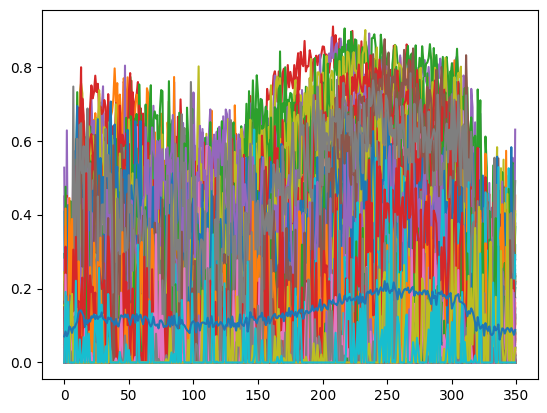

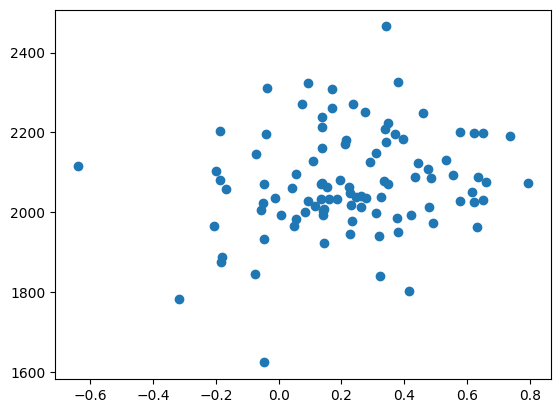

In [45]:
def get_window_averaged_pattern(condition_name, cfg):
    sampling_conversion_factor = cfg.neural_fs / cfg.source_fs
    slice_start, slice_end = np.round(cfg.static_window_ms[0]*sampling_conversion_factor).astype(int), np.round(cfg.static_window_ms[1]*sampling_conversion_factor).astype(int)
    static_window_slice = np.arange(slice_start, slice_end)
    window_averaged_pattern = data[condition_name][:, static_window_slice, :].mean(axis=1)  # channels x stimuli
    if cfg.center_window_averages:
        # Subtract every channel's mean across stimuli (axis 1) after averaging.
        window_averaged_pattern = window_averaged_pattern - window_averaged_pattern.mean(axis=1, keepdims=True)
    # end if cfg.center_window_averages
    return window_averaged_pattern
# EOF
sampling_conversion_factor = cfg.neural_fs / cfg.source_fs
avg_pattern_prev_frame = get_window_averaged_pattern("static_"+cfg.earlier_frame, cfg)
avg_pattern_last_frame = get_window_averaged_pattern("static_"+"last_frame", cfg)
full_corr = np.corrcoef(avg_pattern_last_frame, avg_pattern_prev_frame, rowvar=False)
frame_cross_corr = np.diag(full_corr[:avg_pattern_last_frame.shape[1], avg_pattern_last_frame.shape[1]:])
# plt.imshow(full_corr)
# plt.figure()
# plt.hist(frame_cross_corr)
# corr_lag_mat = 
# for i_stim in range(avg_pattern_last_frame.shape[1]):
#     for t_dyn in range(data["dynamic"].shape[1]):
# # lagged_mat = 
corr_timecourses = []
for t_dyn in range(data["dynamic"].shape[1]):
    curr_t = data["dynamic"][:,t_dyn, :]
    full_corr = np.corrcoef(avg_pattern_last_frame, curr_t, rowvar=False)
    sd_cross_corr = np.diag(full_corr[:avg_pattern_last_frame.shape[1], avg_pattern_last_frame.shape[1]:])
    corr_timecourses.append(sd_cross_corr)

c = np.stack(corr_timecourses, axis=1)
c[c<0] = 0

plt.plot(c.T)
plt.plot(c.mean(axis=0))

dynamic_start = round(cfg.dynamic_window_ms[0] * sampling_conversion_factor)
dynamic_end = round(cfg.dynamic_window_ms[1] * sampling_conversion_factor)
dynamic_window_slice = np.arange(dynamic_start, dynamic_end)
# Bin k covers [k, k + 1) * 10 ms, so its centre is (k + 0.5) * 10 ms.
bin_ms = 1000 / cfg.neural_fs  # 10 ms per bin
window_times_ms = (dynamic_window_slice + 0.5) * bin_ms

weights = c[:, dynamic_window_slice]  # stimuli x window bins, already clipped at 0
weight_sums = weights.sum(axis=1)
# Weighted mean time; NaN for stimuli with no positive correlation in the window.
centroids_ms = np.full(weights.shape[0], np.nan)
np.divide(weights @ window_times_ms, weight_sums, out=centroids_ms, where=weight_sums > 0)

# Peak time for comparison.
peaks_ms = window_times_ms[np.argmax(weights, axis=1)]

from scipy.stats import spearmanr
print(spearmanr(frame_cross_corr, centroids_ms, nan_policy="omit"))
plt.figure()
plt.scatter(frame_cross_corr, centroids_ms)

SignificanceResult(statistic=np.float64(-0.030706335233207004), pvalue=np.float64(0.7701450870979453))


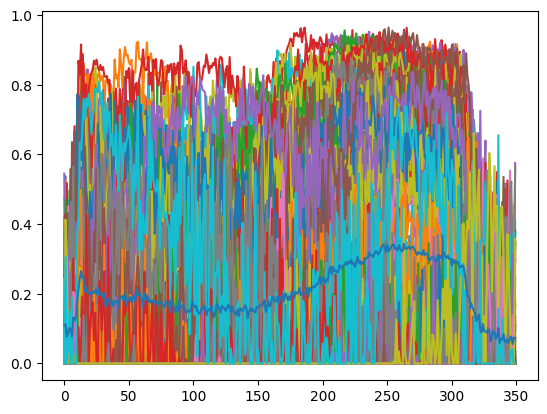

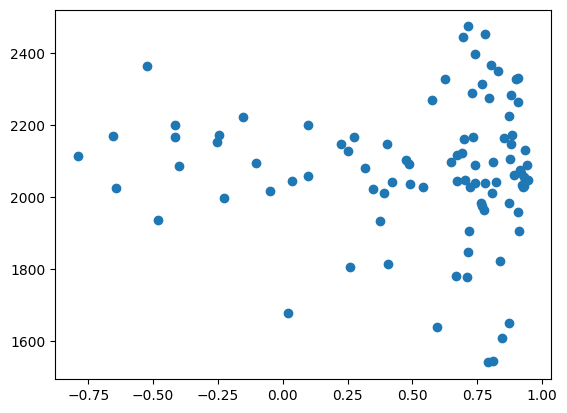

In [46]:

"""
columnwise_cosine
Cosine similarity between matching columns (stimuli) of two channels x stimuli arrays.

INPUT:
    - first: np.ndarray -> channels x stimuli patterns
    - second: np.ndarray -> channels x stimuli patterns

OUTPUT:
    - similarities: np.ndarray -> one cosine per stimulus (NaN if a pattern has zero norm)
"""
def columnwise_cosine(first, second):
    numerators = (first * second).sum(axis=0)  # dot product per stimulus
    denominators = np.linalg.norm(first, axis=0) * np.linalg.norm(second, axis=0)
    similarities = np.full(first.shape[1], np.nan)
    np.divide(numerators, denominators, out=similarities, where=denominators > 0)
    return similarities
# EOF

# Same-video frame similarity: last frame vs earlier frame, one cosine per stimulus.
frame_cross_cos = columnwise_cosine(avg_pattern_last_frame, avg_pattern_prev_frame)

# Per-stimulus timecourse: last-frame pattern vs the movie pattern at every bin.
cos_timecourses = []
for t_dyn in range(data["dynamic"].shape[1]):
    curr_t = data["dynamic"][:, t_dyn, :]  # channels x stimuli
    cos_timecourses.append(columnwise_cosine(avg_pattern_last_frame, curr_t))
# end for t_dyn
c_cos_raw = np.stack(cos_timecourses, axis=1)  # stimuli x time
c_cos = np.clip(c_cos_raw, 0, None)

plt.plot(c_cos.T)
plt.plot(c_cos.mean(axis=0))

weights = c_cos[:, dynamic_window_slice]  # stimuli x window bins
weight_sums = weights.sum(axis=1)
centroids_cos_ms = np.full(weights.shape[0], np.nan)
np.divide(weights @ window_times_ms, weight_sums, out=centroids_cos_ms, where=weight_sums > 0)
peaks_cos_ms = window_times_ms[np.argmax(weights, axis=1)]

print(spearmanr(frame_cross_cos, centroids_cos_ms, nan_policy="omit"))
plt.figure()
plt.scatter(frame_cross_cos, centroids_cos_ms)

In [47]:
frame_cross_corr

array([ 0.13347382,  0.44478395,  0.1408358 ,  0.62344628,  0.47642836,
        0.21246664,  0.15447158,  0.1448465 ,  0.6515009 ,  0.04391794,
        0.05635078,  0.63646592, -0.04662718,  0.632971  ,  0.27849131,
        0.48495927, -0.18546327,  0.04946666, -0.05066216,  0.57797483,
        0.34346776,  0.45958077,  0.13760342,  0.49137419, -0.03800985,
        0.2906183 ,  0.05471438,  0.53465686, -0.31683059,  0.11729001,
        0.19612372, -0.16915342,  0.09392513,  0.55666408,  0.22804128,
        0.08372718, -0.01025139, -0.04761283,  0.24737843,  0.47786901,
        0.13464221,  0.37219541,  0.23019166,  0.23253947, -0.18597467,
       -0.18433881, -0.05616072,  0.22402022,  0.14027817,  0.32200114,
       -0.07239314,  0.31146657,  0.79581833,  0.73854713,  0.6499737 ,
        0.11021779, -0.64087591,  0.13873213,  0.61639117,  0.38015158,
        0.34321453,  0.34993411,  0.26304695,  0.31139147,  0.07548084,
       -0.07411477,  0.23790813, -0.18172175, -0.1991328 ,  0.31

## Frame similarity, similarity curves, and centroids

In [48]:
analysis = compute_frame_similarity_latency(
    data,
    earlier_frame=cfg.earlier_frame,
    static_window_ms=cfg.static_window_ms,
    dynamic_window_ms=cfg.dynamic_window_ms,
    threshold_fraction=cfg.threshold_fraction,
    smoothing_sigma_ms=cfg.smoothing_sigma_ms,
    center_averages=cfg.center_window_averages,
)

result_columns = {
    "stimulus": data["stimuli"],
    f"last_vs_{cfg.earlier_frame}_correlation": analysis["frame_similarity"],
    "centroid_ms": analysis["centroid_ms"],
    "peak_ms": analysis["peak_ms"],
    "peak_r": analysis["peak_values"],
}
stimulus_results = [
    {name: values[index] for name, values in result_columns.items()}
    for index in range(data["stimuli"].size)
]
stimulus_results[:5]

[{'stimulus': np.str_('0_0_41171'),
  'last_vs_2250ms_correlation': np.float64(0.13347397393224464),
  'centroid_ms': np.float64(2189.586672747868),
  'peak_ms': np.float64(2540.0),
  'peak_r': np.float64(0.18490092767874167)},
 {'stimulus': np.str_('1500_animal_names1'),
  'last_vs_2250ms_correlation': np.float64(0.44478397144884546),
  'centroid_ms': np.float64(2418.3423628769224),
  'peak_ms': np.float64(2470.0),
  'peak_r': np.float64(0.4512788400645818)},
 {'stimulus': np.str_('4115_11.01'),
  'last_vs_2250ms_correlation': np.float64(0.1408358169571558),
  'centroid_ms': np.float64(1751.542584275833),
  'peak_ms': np.float64(1750.0),
  'peak_r': np.float64(0.09500267816503329)},
 {'stimulus': np.str_('43.81_41411'),
  'last_vs_2250ms_correlation': np.float64(0.6234463478718141),
  'centroid_ms': np.float64(2030.7081928930224),
  'peak_ms': np.float64(2100.0),
  'peak_r': np.float64(0.8416156560845226)},
 {'stimulus': np.str_('4_5_41241'),
  'last_vs_2250ms_correlation': np.float64

## Check one stimulus

The shaded band is `dynamic_window_ms`; change `example_stimulus_index` above to inspect any stimulus.

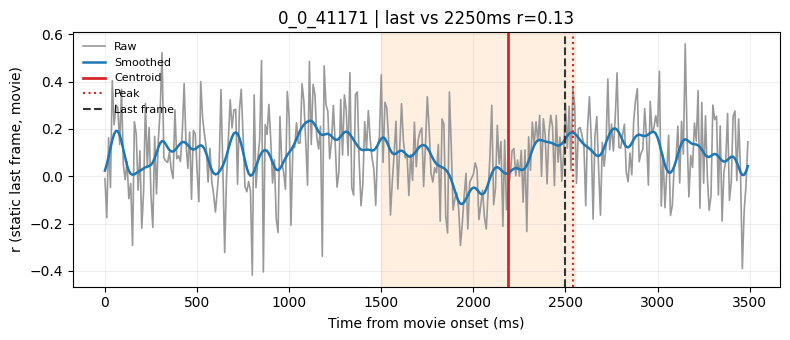

In [49]:
example_figure, _ = plot_centroid_example(
    analysis, data["stimuli"], cfg.example_stimulus_index,
    last_frame_time_ms=cfg.last_frame_time_ms,
)
if cfg.save_figures:
    example_figure.savefig(
        output_dir / "example_centroid.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
# end if cfg.save_figures
plt.show()

## Association over stimuli

Left: every stimulus's curve, sorted by frame similarity (bottom = least similar), with its centroid in red. Middle and right: Spearman association of frame similarity with centroid and peak latency. A negative $\rho$ means more similar frames produce earlier (more anticipatory) last-frame-like movie responses.

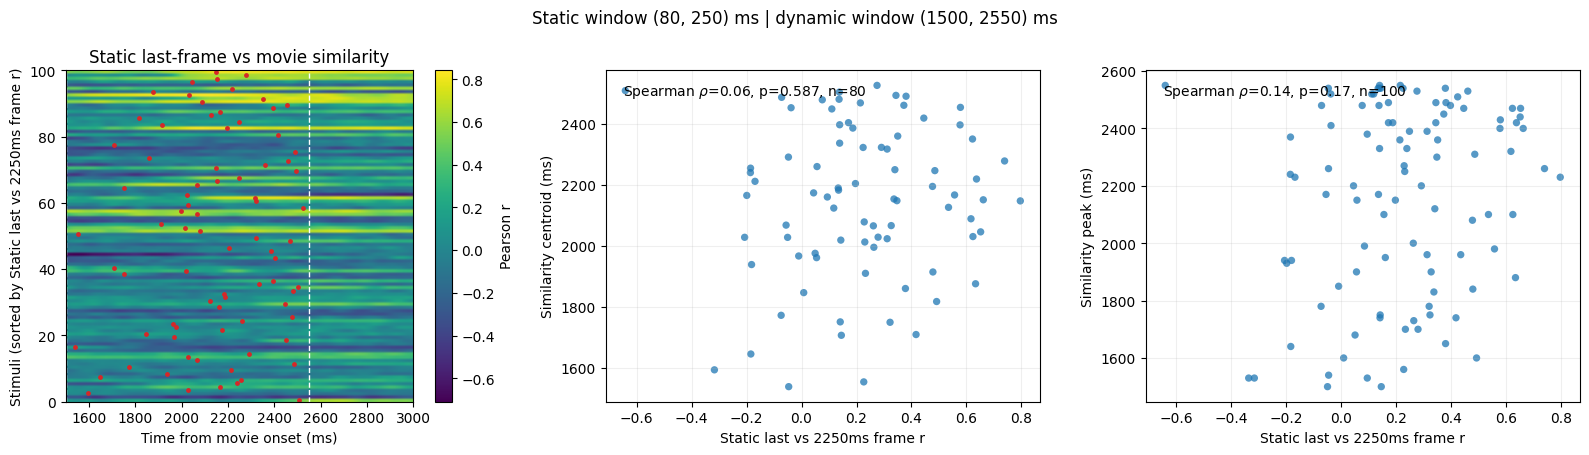

In [50]:
association_figure, _ = plot_frame_similarity_latency(
    analysis, data["stimuli"], annotate_stimuli=cfg.annotate_stimuli,
)
if cfg.save_figures:
    association_figure.savefig(
        output_dir / "frame_similarity_vs_centroid.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
    with open(output_dir / "frame_similarity_centroids.csv", "w", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=result_columns)
        writer.writeheader()
        writer.writerows(stimulus_results)
    # end with open
# end if cfg.save_figures
plt.show()

## Lagged version: max over the full static x movie correlation matrix

For each stimulus, the last-frame pattern at every static time in `lag_static_search_ms` is correlated (across channels) with the same stimulus's movie pattern at every movie time. The maximum over static time gives one lagged curve per stimulus over movie time. Its centroid and peak inside `dynamic_window_ms` are correlated with frame similarity, as above.

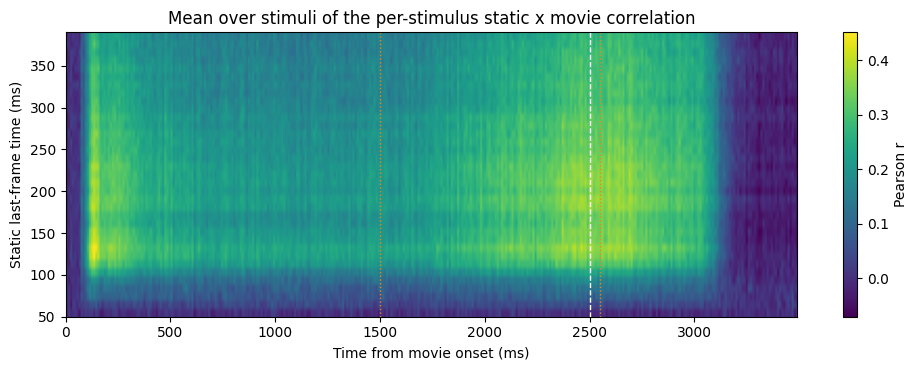

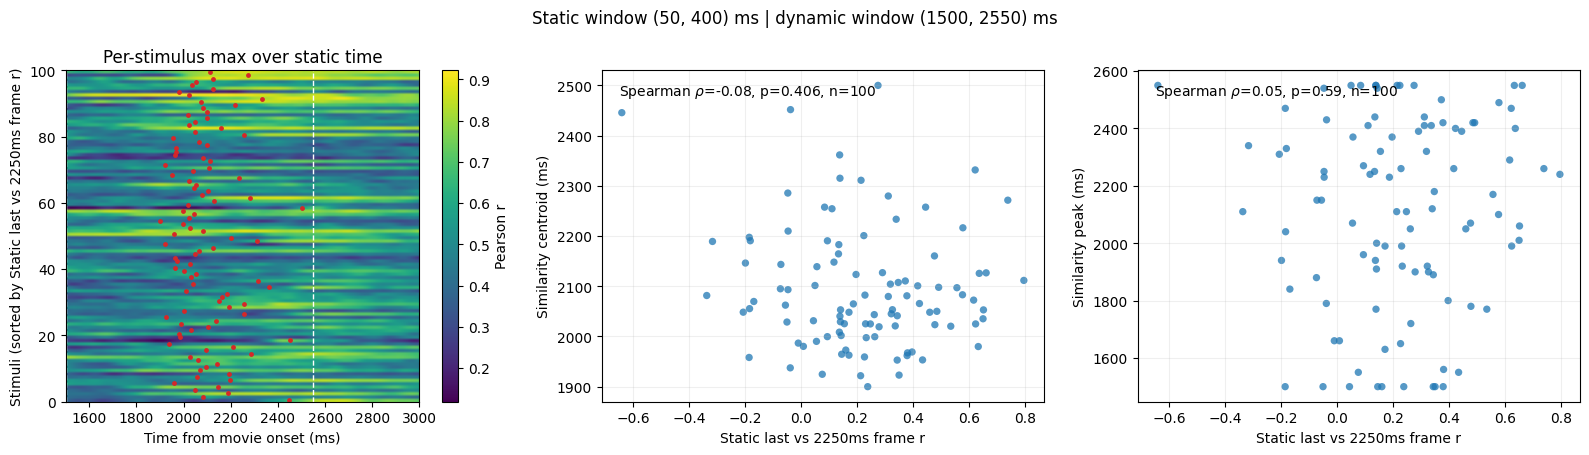

In [51]:
lagged_analysis = compute_lagged_max_latency(
    data, analysis,
    static_search_ms=cfg.lag_static_search_ms,
    smoothing_sigma_ms=cfg.smoothing_sigma_ms,
)
matrix_figure, _ = plot_mean_cross_temporal(
    lagged_analysis, last_frame_time_ms=cfg.last_frame_time_ms,
)
lagged_association_figure, _ = plot_frame_similarity_latency(
    lagged_analysis, data["stimuli"], annotate_stimuli=cfg.annotate_stimuli,
    heatmap_title="Per-stimulus max over static time",
)
if cfg.save_figures:
    matrix_figure.savefig(
        output_dir / "mean_cross_temporal_matrix.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
    lagged_association_figure.savefig(
        output_dir / "frame_similarity_vs_lagged_centroid.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
# end if cfg.save_figures
plt.show()

## Time-resolved association (no centroid)

At every movie time sample, the frame similarity of each stimulus is Spearman-correlated, across stimuli, with that stimulus's static last-frame vs movie correlation at the same sample. A positive $\rho$ before the last frame appears means stimuli with more similar frames already carry a more last-frame-like movie response. The curves used are `centroid_curves`, so they are smoothed only if `smoothing_sigma_ms` is set. The red dots are not corrected for multiple comparisons. The centroid (solid green) and peak (dotted green) of $\rho(t)$ are taken inside `dynamic_window_ms` with the same `threshold_fraction` rule used for the stimulus-level curves.

rho(t) centroid: 2169 ms | peak: 2170 ms (rho=0.22) | window (1500, 2550) ms


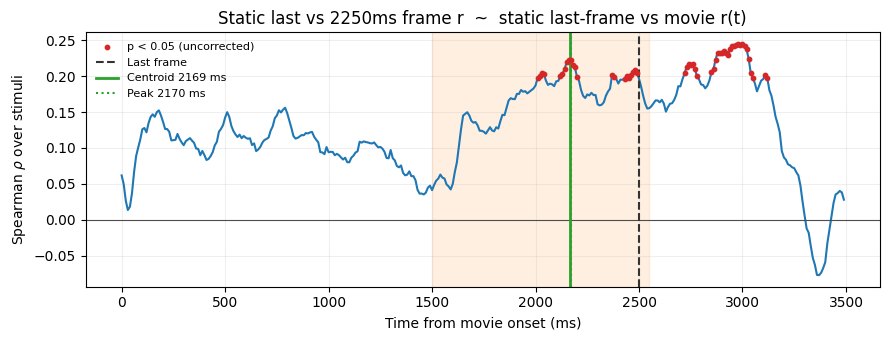

In [52]:
association_rho, association_p = frame_similarity_timecourse_association(
    analysis["frame_similarity"], analysis["centroid_curves"],
)
# The helper expects time x curves, so rho becomes a single-column array.
association_centroid, association_peak, association_peak_rho = (
    similarity_curve_centroids(
        association_rho[:, np.newaxis], analysis["dynamic_times_ms"],
        cfg.dynamic_window_ms, cfg.threshold_fraction,
    )
)
print(
    f"rho(t) centroid: {association_centroid[0]:.0f} ms | "
    f"peak: {association_peak[0]:.0f} ms (rho={association_peak_rho[0]:.2f}) | "
    f"window {cfg.dynamic_window_ms} ms"
)
timecourse_figure, _ = plot_timecourse_association(
    analysis["dynamic_times_ms"], association_rho, association_p,
    earlier_frame=cfg.earlier_frame,
    dynamic_window_ms=cfg.dynamic_window_ms,
    last_frame_time_ms=cfg.last_frame_time_ms,
    centroid_ms=association_centroid[0],
    peak_ms=association_peak[0],
)
if cfg.save_figures:
    timecourse_figure.savefig(
        output_dir / "frame_similarity_timecourse_association.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
# end if cfg.save_figures
plt.show()

## RSA version: window-averaged static RDM vs movie RDM(t)

In the spirit of static dRSA, but the static side is a single RDM built from the `static_window_ms` average of the last-frame response, so only movie time samples are looped over (no static time axis).

- **Population curve:** full static RDM vs movie RDM at each time sample, with its centroid and peak.
- **Stimulus-wise curves:** for each stimulus, its own RDM row (dissimilarities to the other 99 stimuli) in the static window vs the same row at each movie time sample. Centroid and peak are taken inside `dynamic_window_ms` and correlated with the last vs earlier frame similarity, as in the scatterplots above.

Population RSA centroid: 2411 ms | peak: 2550 ms (r=0.56)


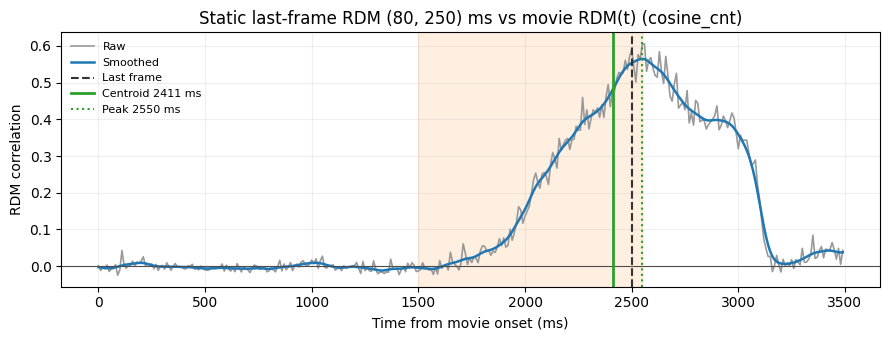

In [53]:
rsa_analysis = compute_frame_similarity_rsa_latency(
    data, analysis,
    rdm_metric=cfg.rdm_metric,
    smoothing_sigma_ms=cfg.smoothing_sigma_ms,
)
print(
    f"Population RSA centroid: {rsa_analysis['population_centroid_ms']:.0f} ms | "
    f"peak: {rsa_analysis['population_peak_ms']:.0f} ms "
    f"(r={rsa_analysis['population_peak_value']:.2f})"
)
population_figure, _ = plot_population_rsa_curve(
    rsa_analysis, last_frame_time_ms=cfg.last_frame_time_ms,
)
if cfg.save_figures:
    population_figure.savefig(
        output_dir / f"population_rsa_curve_{cfg.rdm_metric}.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
# end if cfg.save_figures
plt.show()

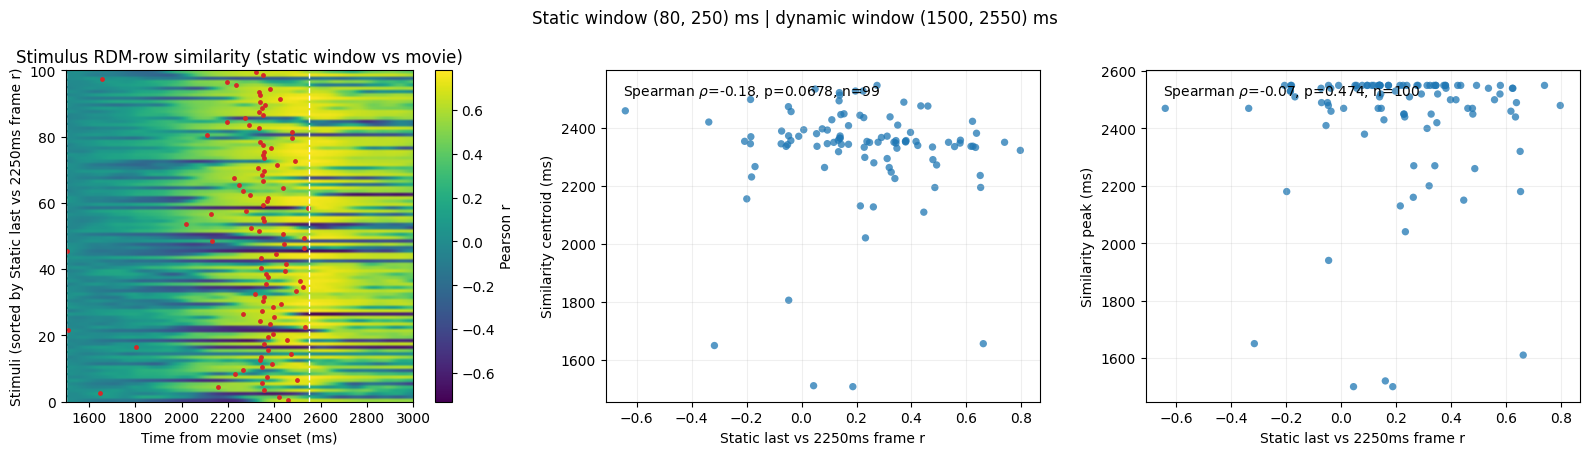

In [54]:
rsa_association_figure, _ = plot_frame_similarity_latency(
    rsa_analysis, data["stimuli"], annotate_stimuli=cfg.annotate_stimuli,
    heatmap_title="Stimulus RDM-row similarity (static window vs movie)",
)
rsa_results = [
    {
        "stimulus": data["stimuli"][index],
        f"last_vs_{cfg.earlier_frame}_correlation": rsa_analysis["frame_similarity"][index],
        "rsa_centroid_ms": rsa_analysis["centroid_ms"][index],
        "rsa_peak_ms": rsa_analysis["peak_ms"][index],
        "rsa_peak_r": rsa_analysis["peak_values"][index],
    }
    for index in range(data["stimuli"].size)
]
if cfg.save_figures:
    rsa_association_figure.savefig(
        output_dir / f"frame_similarity_vs_rsa_centroid_{cfg.rdm_metric}.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
    with open(output_dir / f"frame_similarity_rsa_centroids_{cfg.rdm_metric}.csv", "w", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=rsa_results[0])
        writer.writeheader()
        writer.writerows(rsa_results)
    # end with open
# end if cfg.save_figures
plt.show()

## Anticipation test: last-frame similarity beyond the earlier frame

A higher last-frame similarity before the last frame is shown may simply follow from the earlier frame: the movie response to the earlier frame resembles the static earlier-frame response, which resembles the last frame. To separate this from anticipation, at every movie time the movie pattern is correlated with the last-frame pattern **after partialling out** the earlier-frame pattern (across channels, per stimulus). Its per-stimulus mean in `anticipation_test_window_ms` (after the earlier frame, before the last frame's response can arrive) is compared, paired over stimuli, with `anticipation_baseline_window_ms` (paired Wilcoxon test).

Caveat: the movie shows intermediate frames between the earlier frame and the last one, and those are usually more similar to the last frame. A positive partial correlation is therefore necessary but not sufficient evidence of prediction.

Partial r (last | 2250ms) | test (2300, 2550) ms: 0.106 | baseline (1000, 1500) ms: -0.020 | paired Wilcoxon p=5.08e-10


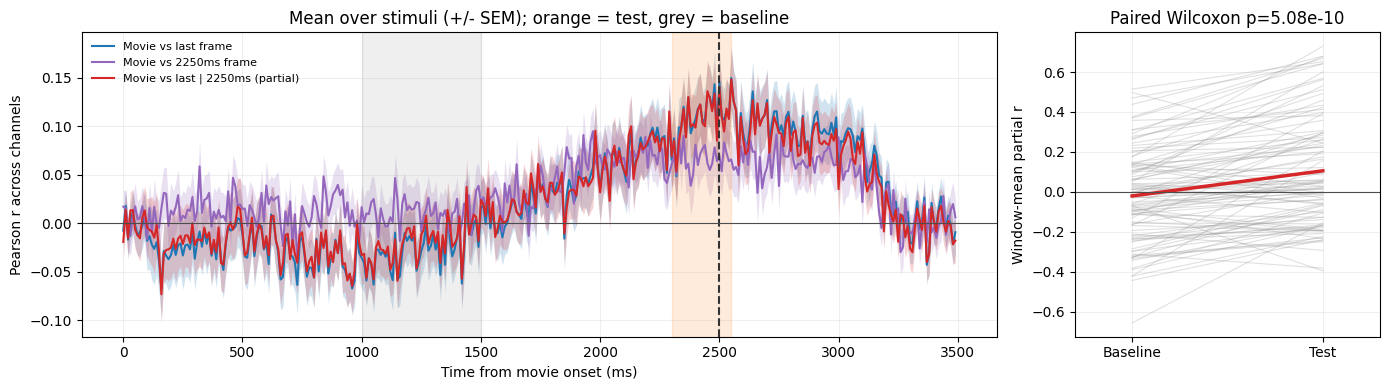

In [55]:
anticipation = compute_anticipation_partial(
    data, analysis,
    test_window_ms=cfg.anticipation_test_window_ms,
    baseline_window_ms=cfg.anticipation_baseline_window_ms,
)
print(
    f"Partial r (last | {cfg.earlier_frame}) | "
    f"test {cfg.anticipation_test_window_ms} ms: {np.nanmean(anticipation['test_partial']):.3f} | "
    f"baseline {cfg.anticipation_baseline_window_ms} ms: {np.nanmean(anticipation['baseline_partial']):.3f} | "
    f"paired Wilcoxon p={anticipation['wilcoxon_p']:.3g}"
)
anticipation_figure, _ = plot_anticipation_partial(
    anticipation, last_frame_time_ms=cfg.last_frame_time_ms,
)
if cfg.save_figures:
    anticipation_figure.savefig(
        output_dir / f"anticipation_partial_{cfg.earlier_frame}.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
# end if cfg.save_figures
plt.show()

## Movie autocorrelation latency vs static frame similarity

For each stimulus, the movie response averaged in `autocorr_reference_window_ms` is correlated (across channels) with the same movie's response at every earlier time sample. The centroid and peak of that curve inside `autocorr_centroid_window_ms` are plotted against the static last vs earlier frame correlation (`static_window_ms` averages). If more similar frames keep the movie response closer to its final state for longer, the autocorrelation mass sits further back in time: the centroid is **earlier**, i.e. a negative correlation with the centroid time and a positive one with the lag `reference start - centroid`.

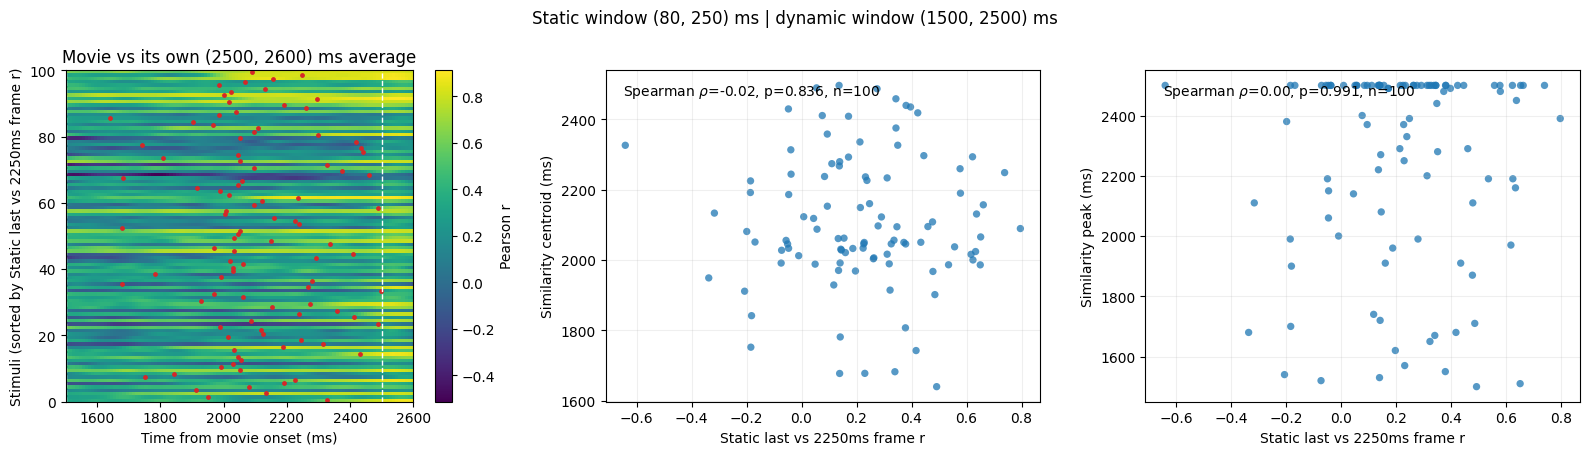

In [56]:
autocorrelation_analysis = compute_dynamic_autocorrelation_latency(
    data, analysis,
    reference_window_ms=cfg.autocorr_reference_window_ms,
    centroid_window_ms=cfg.autocorr_centroid_window_ms,
    smoothing_sigma_ms=cfg.smoothing_sigma_ms,
)
autocorrelation_figure, _ = plot_frame_similarity_latency(
    autocorrelation_analysis, data["stimuli"], annotate_stimuli=cfg.annotate_stimuli,
    display_window_ms=(cfg.autocorr_centroid_window_ms[0], cfg.autocorr_reference_window_ms[1]),
    heatmap_title=f"Movie vs its own {cfg.autocorr_reference_window_ms} ms average",
)
if cfg.save_figures:
    autocorrelation_figure.savefig(
        output_dir / "frame_similarity_vs_movie_autocorrelation_centroid.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
# end if cfg.save_figures
plt.show()

## Cross-channel regression fit vs latency

Correlation compares channels one to one. Here each stimulus's static last-frame pattern is **predicted** through a full channels x channels ridge mapping (plus intercept), so interactions between channels count:

1. from its static earlier-frame pattern (x-axis: *static fit*);
2. from its movie pattern at each movie time, one regression per time (*fit curve*).

A single averaged pattern cannot fit a cross-channel mapping, so every mapping is fitted on the other 99 stimuli (leave-one-stimulus-out) and then applied to the held-out stimulus. The fit is the Pearson correlation across channels between predicted and actual last-frame pattern. The centroid and peak of the fit curve in `regression_centroid_window_ms` are plotted against the static fit. Prediction: better static fit gives an earlier centroid (negative $\rho$).

Static fit (last | 2250ms, LOO ridge): mean r=0.37, 82% of stimuli > 0 | raw frame correlation mean r=0.22


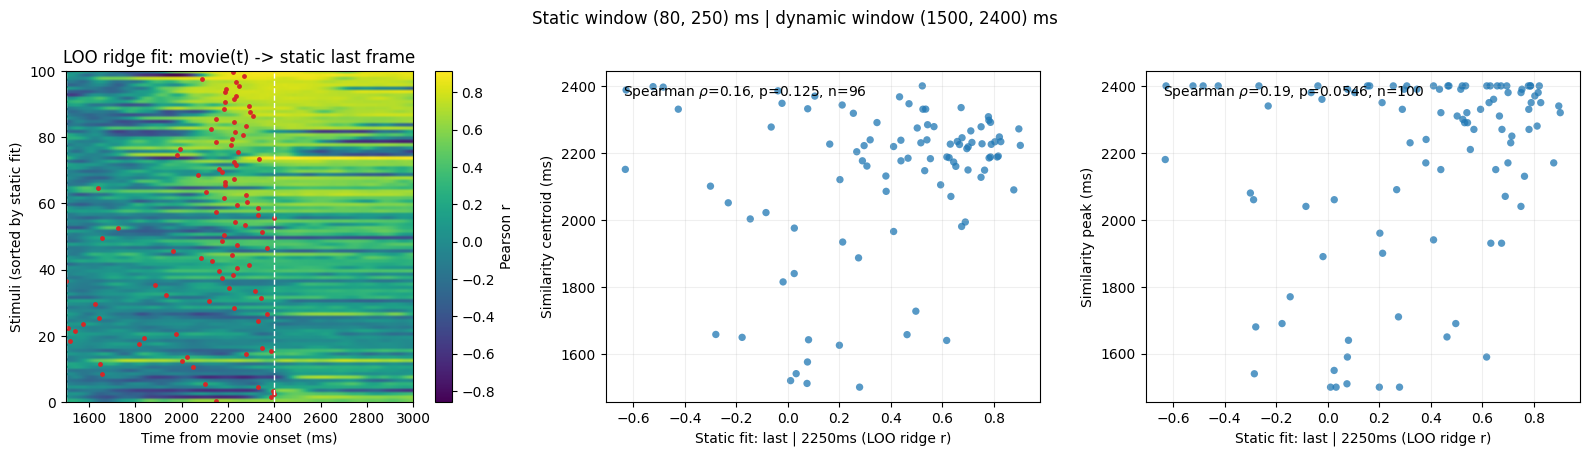

In [57]:
regression_analysis = compute_regression_fit_latency(
    data, analysis,
    ridge_alpha=cfg.ridge_alpha,
    centroid_window_ms=cfg.regression_centroid_window_ms,
    smoothing_sigma_ms=cfg.smoothing_sigma_ms,
)
print(
    f"Static fit (last | {cfg.earlier_frame}, LOO ridge): "
    f"mean r={np.nanmean(regression_analysis['frame_similarity']):.2f}, "
    f"{np.mean(regression_analysis['frame_similarity'] > 0):.0%} of stimuli > 0 | "
    f"raw frame correlation mean r={np.nanmean(regression_analysis['raw_frame_similarity']):.2f}"
)
regression_figure, _ = plot_frame_similarity_latency(
    regression_analysis, data["stimuli"], annotate_stimuli=cfg.annotate_stimuli,
    heatmap_title="LOO ridge fit: movie(t) -> static last frame",
)
regression_figure.axes[1].set_xlabel(f"Static fit: last | {cfg.earlier_frame} (LOO ridge r)")
regression_figure.axes[2].set_xlabel(f"Static fit: last | {cfg.earlier_frame} (LOO ridge r)")
regression_figure.axes[0].set_ylabel("Stimuli (sorted by static fit)")
if cfg.save_figures:
    regression_figure.savefig(
        output_dir / f"regression_fit_vs_centroid_alpha{cfg.ridge_alpha}.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
# end if cfg.save_figures
plt.show()

## Static frame correlation vs movie window correlation

x: per-stimulus correlation (across channels) of the static last-frame and earlier-frame patterns (`static_window_ms` averages). y: per-stimulus correlation of the movie patterns averaged in `movie_first_window_ms` and `movie_second_window_ms`. If the movie response carries the frame content, stimuli whose frames evoke more similar static responses should also show more similar movie responses across the two windows (positive $\rho$).

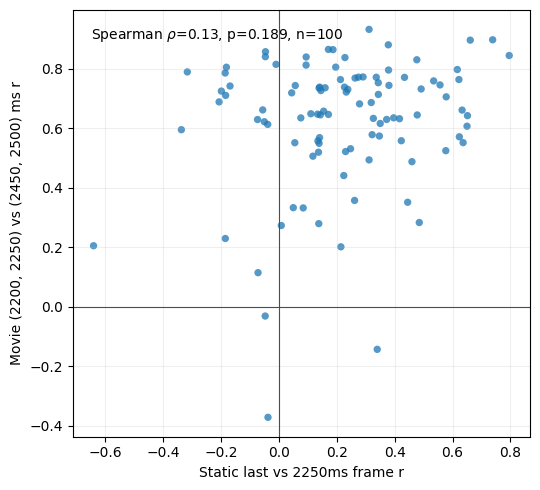

In [61]:
movie_window_similarity = dynamic_window_similarity(
    data, cfg.movie_first_window_ms, cfg.movie_second_window_ms,
    center_averages=cfg.center_window_averages,
)
window_pair_figure, _ = plot_static_dynamic_window_similarity(
    analysis["frame_similarity"], movie_window_similarity,
    cfg.earlier_frame, cfg.movie_first_window_ms, cfg.movie_second_window_ms,
    stimulus_names=data["stimuli"] if cfg.annotate_stimuli else None,
)
if cfg.save_figures:
    window_pair_figure.savefig(
        output_dir / "static_vs_movie_window_similarity.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
# end if cfg.save_figures
plt.show()

## Same comparison with leave-one-out cross-channel regression

x: static fit from the regression section (last-frame pattern predicted from the earlier-frame pattern). y: each stimulus's `movie_second_window_ms` pattern predicted from its `movie_first_window_ms` pattern with the same leave-one-stimulus-out ridge (`ridge_alpha`), scored by the correlation between predicted and actual patterns. Caveat: each fit also depends on how predictable the stimulus's target pattern is through a mapping shared across stimuli, which can inflate the association.

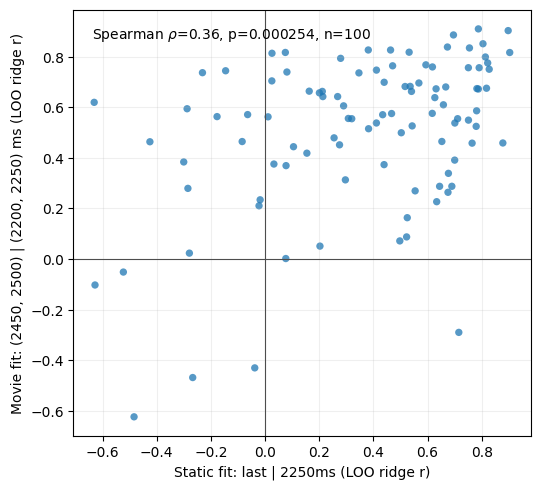

In [62]:
movie_window_fit = dynamic_window_regression_fit(
    data, cfg.movie_first_window_ms, cfg.movie_second_window_ms, cfg.ridge_alpha,
    center_averages=cfg.center_window_averages,
)
window_pair_regression_figure, window_pair_axis = plot_static_dynamic_window_similarity(
    regression_analysis["frame_similarity"], movie_window_fit,
    cfg.earlier_frame, cfg.movie_first_window_ms, cfg.movie_second_window_ms,
    stimulus_names=data["stimuli"] if cfg.annotate_stimuli else None,
)
window_pair_axis.set(
    xlabel=f"Static fit: last | {cfg.earlier_frame} (LOO ridge r)",
    ylabel=f"Movie fit: {cfg.movie_second_window_ms} | {cfg.movie_first_window_ms} ms (LOO ridge r)",
)
if cfg.save_figures:
    window_pair_regression_figure.savefig(
        output_dir / f"static_vs_movie_window_regression_alpha{cfg.ridge_alpha}.png",
        dpi=cfg.figure_dpi, bbox_inches="tight",
    )
# end if cfg.save_figures
plt.show()